In [54]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import kruskal
import seaborn as sns
import matplotlib.pyplot as plt

In [55]:
###########################  Modified 2025 for loading  ###########################
curRoot = 'C'  # 'C' or 'D'

# Load shape measures
shape_path = rf'{curRoot}:\A_joyCODE\DEV_LIN\ampExt\CSSyl\Isomap\isomapCmdsCSSylk10d3distmin_keepOut.txt'      # Region CSSyl
#shape_path = rf'{curRoot}:\A_joyCODE\DEV_LIN\ampExt\CSpreCS\Isomap\isomapCmdsCSpreCSk10d3distmin_keepOut.txt' # Region CSpreCS
shapeU_1_path = rf'{curRoot}:\A_joyCODE\DEV_LIN\Shape_study\CSSyl\AmpExt_Umap\dim1_neig5_minDist0.2.txt'
shapeU_2_path = rf'{curRoot}:\A_joyCODE\DEV_LIN\Shape_study\CSSyl\AmpExt_Umap\dim1_neig30_minDist0.2.txt'
shapeU_3_path = rf'{curRoot}:\A_joyCODE\DEV_LIN\Shape_study\CSSyl\AmpExt_Umap\dim2_neig5_minDist0.2.txt'
shapeU_4_path = rf'{curRoot}:\A_joyCODE\DEV_LIN\Shape_study\CSSyl\AmpExt_Umap\dim2_neig30_minDist0.2.txt'
#shapeU_4_path = r'D:\A_joyCODE\DEV_LIN\Shape_study\CSSyl\AmpExt_Umap\dim3_neig5_minDist0.2.txt'
try:
    shape = pd.read_csv(shape_path, index_col=0, header=0)
    print(shape.head())
    shapeU_1 = pd.read_csv(shapeU_1_path, index_col=0, header=0)
    shapeU_2 = pd.read_csv(shapeU_2_path, index_col=0, header=0)
    shapeU_3 = pd.read_csv(shapeU_3_path, index_col=0, header=0)
    shapeU_4 = pd.read_csv(shapeU_4_path, index_col=0, header=0)

    shapeU_1.rename(columns={'UMAP1': 'UMAP1_U1'}, inplace=True)
    shapeU_2.rename(columns={'UMAP1': 'UMAP1_U2'}, inplace=True)
    shapeU_3.rename(columns={'UMAP1': 'UMAP1_U3', 'UMAP2': 'UMAP2_U3'}, inplace=True)
    shapeU_4.rename(columns={'UMAP1': 'UMAP1_U4', 'UMAP2': 'UMAP2_U4'}, inplace=True)
    #shapeU_4.rename(columns={'UMAP1': 'UMAP1_U4', 'UMAP2': 'UMAP2_U4','UMAP3': 'UMAP3_U4'}, inplace=True)
except FileNotFoundError as e:
    print(f"Error: {e}")

#shape_joined = shape.join(shapeU)
shape_joined = shape.join([shapeU_1, shapeU_2, shapeU_3, shapeU_4])
shape = shape_joined
#print(shape.head())

                     1         2         3
subjName                                  
LPC24_struct -3.129764 -0.129110 -1.895557
LPC05_struct -3.857513 -3.494893  1.386982
LPA30_struct  4.102761  1.443144 -0.599581
LPC21_struct -1.398569 -1.033002  0.397889
LPA32_struct -3.843092  2.432006  1.754709


# Load shape measures
shape_path = r'D:\A_joyCODE\DEV_LIN\ampExt\CSSyl\Isomap\isomapCmdsCSSylk10d3distmin_keepOut.txt'
shapeU_1_path = r'D:\A_joyCODE\DEV_LIN\Shape_study\CSSyl\AmpExt_Umap\dim1_neig5_minDist0.2.txt'
shapeU_2_path = r'D:\A_joyCODE\DEV_LIN\Shape_study\CSSyl\AmpExt_Umap\dim1_neig30_minDist0.2.txt'
shapeU_3_path = r'D:\A_joyCODE\DEV_LIN\Shape_study\CSSyl\AmpExt_Umap\dim2_neig5_minDist0.2.txt'
shapeU_4_path = r'D:\A_joyCODE\DEV_LIN\Shape_study\CSSyl\AmpExt_Umap\dim2_neig30_minDist0.2.txt'
#shapeU_4_path = r'D:\A_joyCODE\DEV_LIN\Shape_study\CSSyl\AmpExt_Umap\dim3_neig5_minDist0.2.txt'
try:
    shape = pd.read_csv(shape_path, index_col=0, header=0)
    print(shape.head())
    shapeU_1 = pd.read_csv(shapeU_1_path, index_col=0, header=0)
    shapeU_2 = pd.read_csv(shapeU_2_path, index_col=0, header=0)
    shapeU_3 = pd.read_csv(shapeU_3_path, index_col=0, header=0)
    shapeU_4 = pd.read_csv(shapeU_4_path, index_col=0, header=0)

    shapeU_1.rename(columns={'UMAP1': 'UMAP1_U1'}, inplace=True)
    shapeU_2.rename(columns={'UMAP1': 'UMAP1_U2'}, inplace=True)
    shapeU_3.rename(columns={'UMAP1': 'UMAP1_U3', 'UMAP2': 'UMAP2_U3'}, inplace=True)
    shapeU_4.rename(columns={'UMAP1': 'UMAP1_U4', 'UMAP2': 'UMAP2_U4'}, inplace=True)
    #shapeU_4.rename(columns={'UMAP1': 'UMAP1_U4', 'UMAP2': 'UMAP2_U4','UMAP3': 'UMAP3_U4'}, inplace=True)
except FileNotFoundError as e:
    print(f"Error: {e}")

#shape_joined = shape.join(shapeU)
shape_joined = shape.join([shapeU_1, shapeU_2, shapeU_3, shapeU_4])
shape = shape_joined
#print(shape.head())

In [57]:
# Modify the subject names of shape measures to agree with that of the INFO files
# Remove all postfix
def remove_postfix(index_name):
    return index_name.split('_')[0]
shape['index_modified'] = shape.index.map(remove_postfix)
shape_indexed = shape.set_index('index_modified') 
#print("\nDataFrame with Modified Index Column:")
#print(shape_indexed)

In [58]:
# Load anatomical and functional info 
amp_info_path = rf'{curRoot}:\B_projWIP\proj_amputee\amputee_INFO_result\allinfoAmputeeJoy.csv'
function_path = rf'{curRoot}:\B_projWIP\proj_amputee\amputee_INFO_result\Functional_plasticity.csv'
try:
    shape_info = pd.read_csv(amp_info_path, index_col=0, header=0)
#    print("***********  Shape INFO  ************")
#    print(shape_info.head())
    function_info = pd.read_csv(function_path,index_col=0, header=0)
#    print("***********  Activation congenital INFO  ************")
#    print(function_info.head())
except FileNotFoundError as e:
    print(f"Error: {e}")
# set subjID as index for function_info
function_info_reset = function_info.reset_index()
function_info_reset.set_index('subjID', inplace=True)
function_info = function_info_reset
#print(function_info.head())

In [59]:
# Double shape_info to account for the two hemisphere
shape_info_L = shape_info.copy()
shape_info_flip_R = shape_info.copy()
# Append 'L' to the index of the first copy
shape_info_L.index = 'L' + shape_info_L.index
# Append 'flip_R' to the index of the second copy
shape_info_flip_R.index = 'flip-R' + shape_info_flip_R.index
# Compose the new info df with the new index
shape_info_LR_combined = pd.concat([shape_info_L, shape_info_flip_R])
#print(shape_info_LR_combined)

# Do the same for function_info
function_info_L = function_info.copy()
function_info_flip_R = function_info.copy()
function_info_L.index = 'L' + function_info_L.index
function_info_flip_R.index = 'flip-R' + function_info_flip_R.index
function_info_LR_combined = pd.concat([function_info_L, function_info_flip_R])
print(function_info_LR_combined.columns)

Index(['study', 'gender', 'amp.side', 'birthyear', 'Prosthesisusage',
       'Stumpusage', 'amputatio level', 'Cos', 'Fun', 'Myo', 'missinghand',
       'intacthand', 'residualarm', 'intactarm', 'lips', 'feet'],
      dtype='object')


In [60]:
# Join INFO with shape measures
desired_columns = ['1', '2', '3','UMAP1_U1','UMAP1_U2','UMAP1_U3','UMAP2_U3','UMAP1_U4','UMAP2_U4'] 
# IF needing additional columns
#desired_columns = ['1', '2', '3','UMAP1_U1','UMAP1_U2','UMAP1_U3','UMAP2_U3','UMAP1_U4','UMAP2_U4','UMAP3_U4'] 
#joined_info_shape = pd.concat([shape_info_LR_combined, shape_indexed[desired_columns]], axis=1)


# Inner join on index, selecting desired columns from df2
joined_info_shape = shape_info_LR_combined.merge(shape_indexed[desired_columns], how='inner', left_index=True, right_index=True)


#joined_info_shape = pd.merge([shape_info_LR_combined, shape_indexed[desired_columns]])
print(joined_info_shape.columns)

Index(['Gender', 'AgeScan', 'AgeLimbLoss', 'Group', 'AmpSide', 'DominantHand',
       '1', '2', '3', 'UMAP1_U1', 'UMAP1_U2', 'UMAP1_U3', 'UMAP2_U3',
       'UMAP1_U4', 'UMAP2_U4'],
      dtype='object')


In [61]:
# Adding additional columns: side, contraAmpSide and study
# Shape measure rename
# Define joined_info_function

def classify_index(index_name):
  """Classifies the index name with 'L' for 'l' and 'R' for 'f'."""
  if index_name.startswith('L'):
    return 'L'
  elif index_name.startswith('f'):
    return 'R'
  else:
    # Handle cases where the index doesn't start with 'l' or 'f' (optional)
    return None  # Or any other default value

# Add a column 'side' for the hemisphere of shape
joined_info_shape['side'] = joined_info_shape.index.map(classify_index)

# Define a function to determine 'contraAmpSide'
def get_contra_amp_side(amp_side):
    if amp_side == 'L':
        return 'R'
    elif amp_side == 'R':
        return 'L'
    else:
        return 'none'
# Apply the function to create contraAmpSide column for the contralateral side of the missing hand
joined_info_shape['contraAmpSide'] = joined_info_shape['AmpSide'].apply(get_contra_amp_side)

# Add a study column default to 1
study_column = pd.Series(1, index=joined_info_shape.index)
joined_info_shape['study'] = study_column

# Rename the shape columns
column_mapping = {'1': 'iso1', '2': 'iso2', '3': 'iso3'}
joined_info_shape.rename(columns=column_mapping, inplace=True)

# Define joined_info_function
desired_columns = ['side','contraAmpSide','iso1', 'iso2', 'iso3','UMAP1_U1','UMAP1_U2','UMAP1_U3','UMAP2_U3','UMAP1_U4','UMAP2_U4'] 
# IF needing additional columns
#desired_columns = ['side','contraAmpSide','iso1', 'iso2', 'iso3','UMAP1_U1','UMAP1_U2','UMAP1_U3','UMAP2_U3','UMAP1_U4','UMAP2_U4','UMAP3_U4'] 
#joined_info_function = pd.concat([function_info_LR_combined, joined_info_shape[desired_columns]], axis=1)
joined_info_function = function_info_LR_combined.merge(joined_info_shape[desired_columns],how='inner',left_index=True, right_index=True)


#print('*** function_info_LR_combined ***')
#print(function_info_LR_combined.columns)
#print(len(function_info_LR_combined))
print('*** joined_info_shape ***')
print(len(joined_info_shape))
print(joined_info_shape.columns)
print('*** joined_info_function ***')
print(len(joined_info_function))
print(joined_info_function.columns)

*** joined_info_shape ***
130
Index(['Gender', 'AgeScan', 'AgeLimbLoss', 'Group', 'AmpSide', 'DominantHand',
       'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2', 'UMAP1_U3', 'UMAP2_U3',
       'UMAP1_U4', 'UMAP2_U4', 'side', 'contraAmpSide', 'study'],
      dtype='object')
*** joined_info_function ***
48
Index(['study', 'gender', 'amp.side', 'birthyear', 'Prosthesisusage',
       'Stumpusage', 'amputatio level', 'Cos', 'Fun', 'Myo', 'missinghand',
       'intacthand', 'residualarm', 'intactarm', 'lips', 'feet', 'side',
       'contraAmpSide', 'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2',
       'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4'],
      dtype='object')


In [62]:
################################  Debug 2025: Saving csv files for comparison  #################################
curRoot = 'C'
curProject = 'amputee'
curRegion = 'CSSyl'
curDistType = 'min'
file_path = rf'{curRoot}:\B_projWIP\proj_{curProject}\Analysis_2025\{curRegion}_joined_shape_{curDistType}.csv'
print(file_path)

# Write the DataFrame to a CSV file
joined_info_shape.to_csv(file_path, index=True)


C:\B_projWIP\proj_amputee\Analysis_2025\CSSyl_joined_shape_min.csv


In [63]:
# For anatomical analysis: select amptutee data, contra
ampContraL = joined_info_shape[
    (joined_info_shape['Group'] == 'AMP') &
    (joined_info_shape['contraAmpSide'] == joined_info_shape['side']) &
    (joined_info_shape['side'] == 'L')
]
ampContraR = joined_info_shape[
    (joined_info_shape['Group'] == 'AMP') &
    (joined_info_shape['contraAmpSide'] == joined_info_shape['side']) &
    (joined_info_shape['side'] == 'R')
]
ampContra = pd.concat([ampContraL, ampContraR], axis=0)
# select amputee data, ipsi
ampIpsiL = joined_info_shape[
    (joined_info_shape['Group'] == 'AMP') &
    (joined_info_shape['AmpSide'] == joined_info_shape['side']) &
    (joined_info_shape['side'] == 'L')
]
ampIpsiR = joined_info_shape[
    (joined_info_shape['Group'] == 'AMP') &
    (joined_info_shape['AmpSide'] == joined_info_shape['side']) &
    (joined_info_shape['side'] == 'R')
]
ampIpsi = pd.concat([ampIpsiL, ampIpsiR], axis=0)
# select congenital data, contra
congContraL = joined_info_shape[
    (joined_info_shape['Group'] == 'CONG') &
    (joined_info_shape['contraAmpSide'] == joined_info_shape['side']) &
    (joined_info_shape['side'] == 'L')
]
congContraR = joined_info_shape[
    (joined_info_shape['Group'] == 'CONG') &
    (joined_info_shape['contraAmpSide'] == joined_info_shape['side']) &
    (joined_info_shape['side'] == 'R')
]
congContra = pd.concat([congContraL, congContraR], axis=0)
# select congenital data, ipsi
congIpsiL = joined_info_shape[
    (joined_info_shape['Group'] == 'CONG') &
    (joined_info_shape['AmpSide'] == joined_info_shape['side']) &
    (joined_info_shape['side'] == 'L')
]
congIpsiR = joined_info_shape[
    (joined_info_shape['Group'] == 'CONG') &
    (joined_info_shape['AmpSide'] == joined_info_shape['side']) &
    (joined_info_shape['side'] == 'R')
]
congIpsi = pd.concat([congIpsiL, congIpsiR], axis=0)
# select control data
ctrL = joined_info_shape[
    (joined_info_shape['Group'] == 'CTR') &
    (joined_info_shape['side'] == 'L')
]
ctrR = joined_info_shape[
    (joined_info_shape['Group'] == 'CTR') &
    (joined_info_shape['side'] == 'R')
]
ctr = pd.concat([ctrL,ctrR],axis=0)
# amp and cong group
amp = joined_info_shape[(joined_info_shape['Group'] == 'AMP')]
cong = joined_info_shape[(joined_info_shape['Group'] == 'CONG')]
# contra and ipsi of missing hand group
contra = pd.concat([congContra, ampContra, ctr], axis=0)
ipsi = pd.concat([congIpsi, ampIpsi, ctr], axis=0)

# contraCtrL and contraCtrR
contraCtrL = pd.concat([congContraL, ampContraL, ctrL], axis=0)
contraCtrR = pd.concat([congContraR, ampContraR, ctrR], axis=0)
# ipsiCtrL and ipsiCtrR
ipsiCtrL = pd.concat([congIpsiL, ampIpsiL, ctrL], axis=0)
ipsiCtrR = pd.concat([congIpsiR, ampIpsiR, ctrR], axis=0)

print('congContra:')
print(len(congContra))
print('ampContra:')
print(len(ampContra))
print('amp:')
print(len(amp))
#print(amp.index)
print('cong')
print(len(cong))
#print(cong.index)
print('ctr')
print(len(ctr))
print(ctr.columns)
print('contra')
print(len(contra))
print(contra.columns)
print('ipsi')
print(len(ipsi))
#print(ipsi.index)

congContra:
25
ampContra:
16
amp:
32
cong
50
ctr
48
Index(['Gender', 'AgeScan', 'AgeLimbLoss', 'Group', 'AmpSide', 'DominantHand',
       'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2', 'UMAP1_U3', 'UMAP2_U3',
       'UMAP1_U4', 'UMAP2_U4', 'side', 'contraAmpSide', 'study'],
      dtype='object')
contra
89
Index(['Gender', 'AgeScan', 'AgeLimbLoss', 'Group', 'AmpSide', 'DominantHand',
       'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2', 'UMAP1_U3', 'UMAP2_U3',
       'UMAP1_U4', 'UMAP2_U4', 'side', 'contraAmpSide', 'study'],
      dtype='object')
ipsi
89


In [146]:
############################  Verifications, 2025  ############################

col = contra['UMAP1_U1']

# Quick summary: count, mean, std, min, quartiles, max
print(col.describe())

# Median
print("Median:", col.median())

# Specific quantiles
print("25th percentile (Q1):", col.quantile(0.25))
print("50th percentile (Q2/median):", col.quantile(0.5))
print("75th percentile (Q3):", col.quantile(0.75))

# Mean and standard deviation
print("Mean:", col.mean())
print("Std dev:", col.std())

count    89.000000
mean      2.688515
std       5.976225
min      -7.674470
25%      -2.111303
50%       1.739678
75%       8.173648
max      12.632370
Name: UMAP1_U1, dtype: float64
Median: 1.7396784
25th percentile (Q1): -2.1113033
50th percentile (Q2/median): 1.7396784
75th percentile (Q3): 8.173648
Mean: 2.688514521235955
Std dev: 5.976225421612241


C:\Users\joyca\AppData\Local\Temp\ipykernel_38748\164874173.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=shape, data=contraCtrL, palette='Set2', ax=axes[i, 0])
C:\Users\joyca\AppData\Local\Temp\ipykernel_38748\164874173.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=shape, data=contraCtrR, palette='Set2', ax=axes[i, 1])
C:\Users\joyca\AppData\Local\Temp\ipykernel_38748\164874173.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=shape, data=contraCtrL, palette='Set2', ax=axes[i, 0])
C:\U

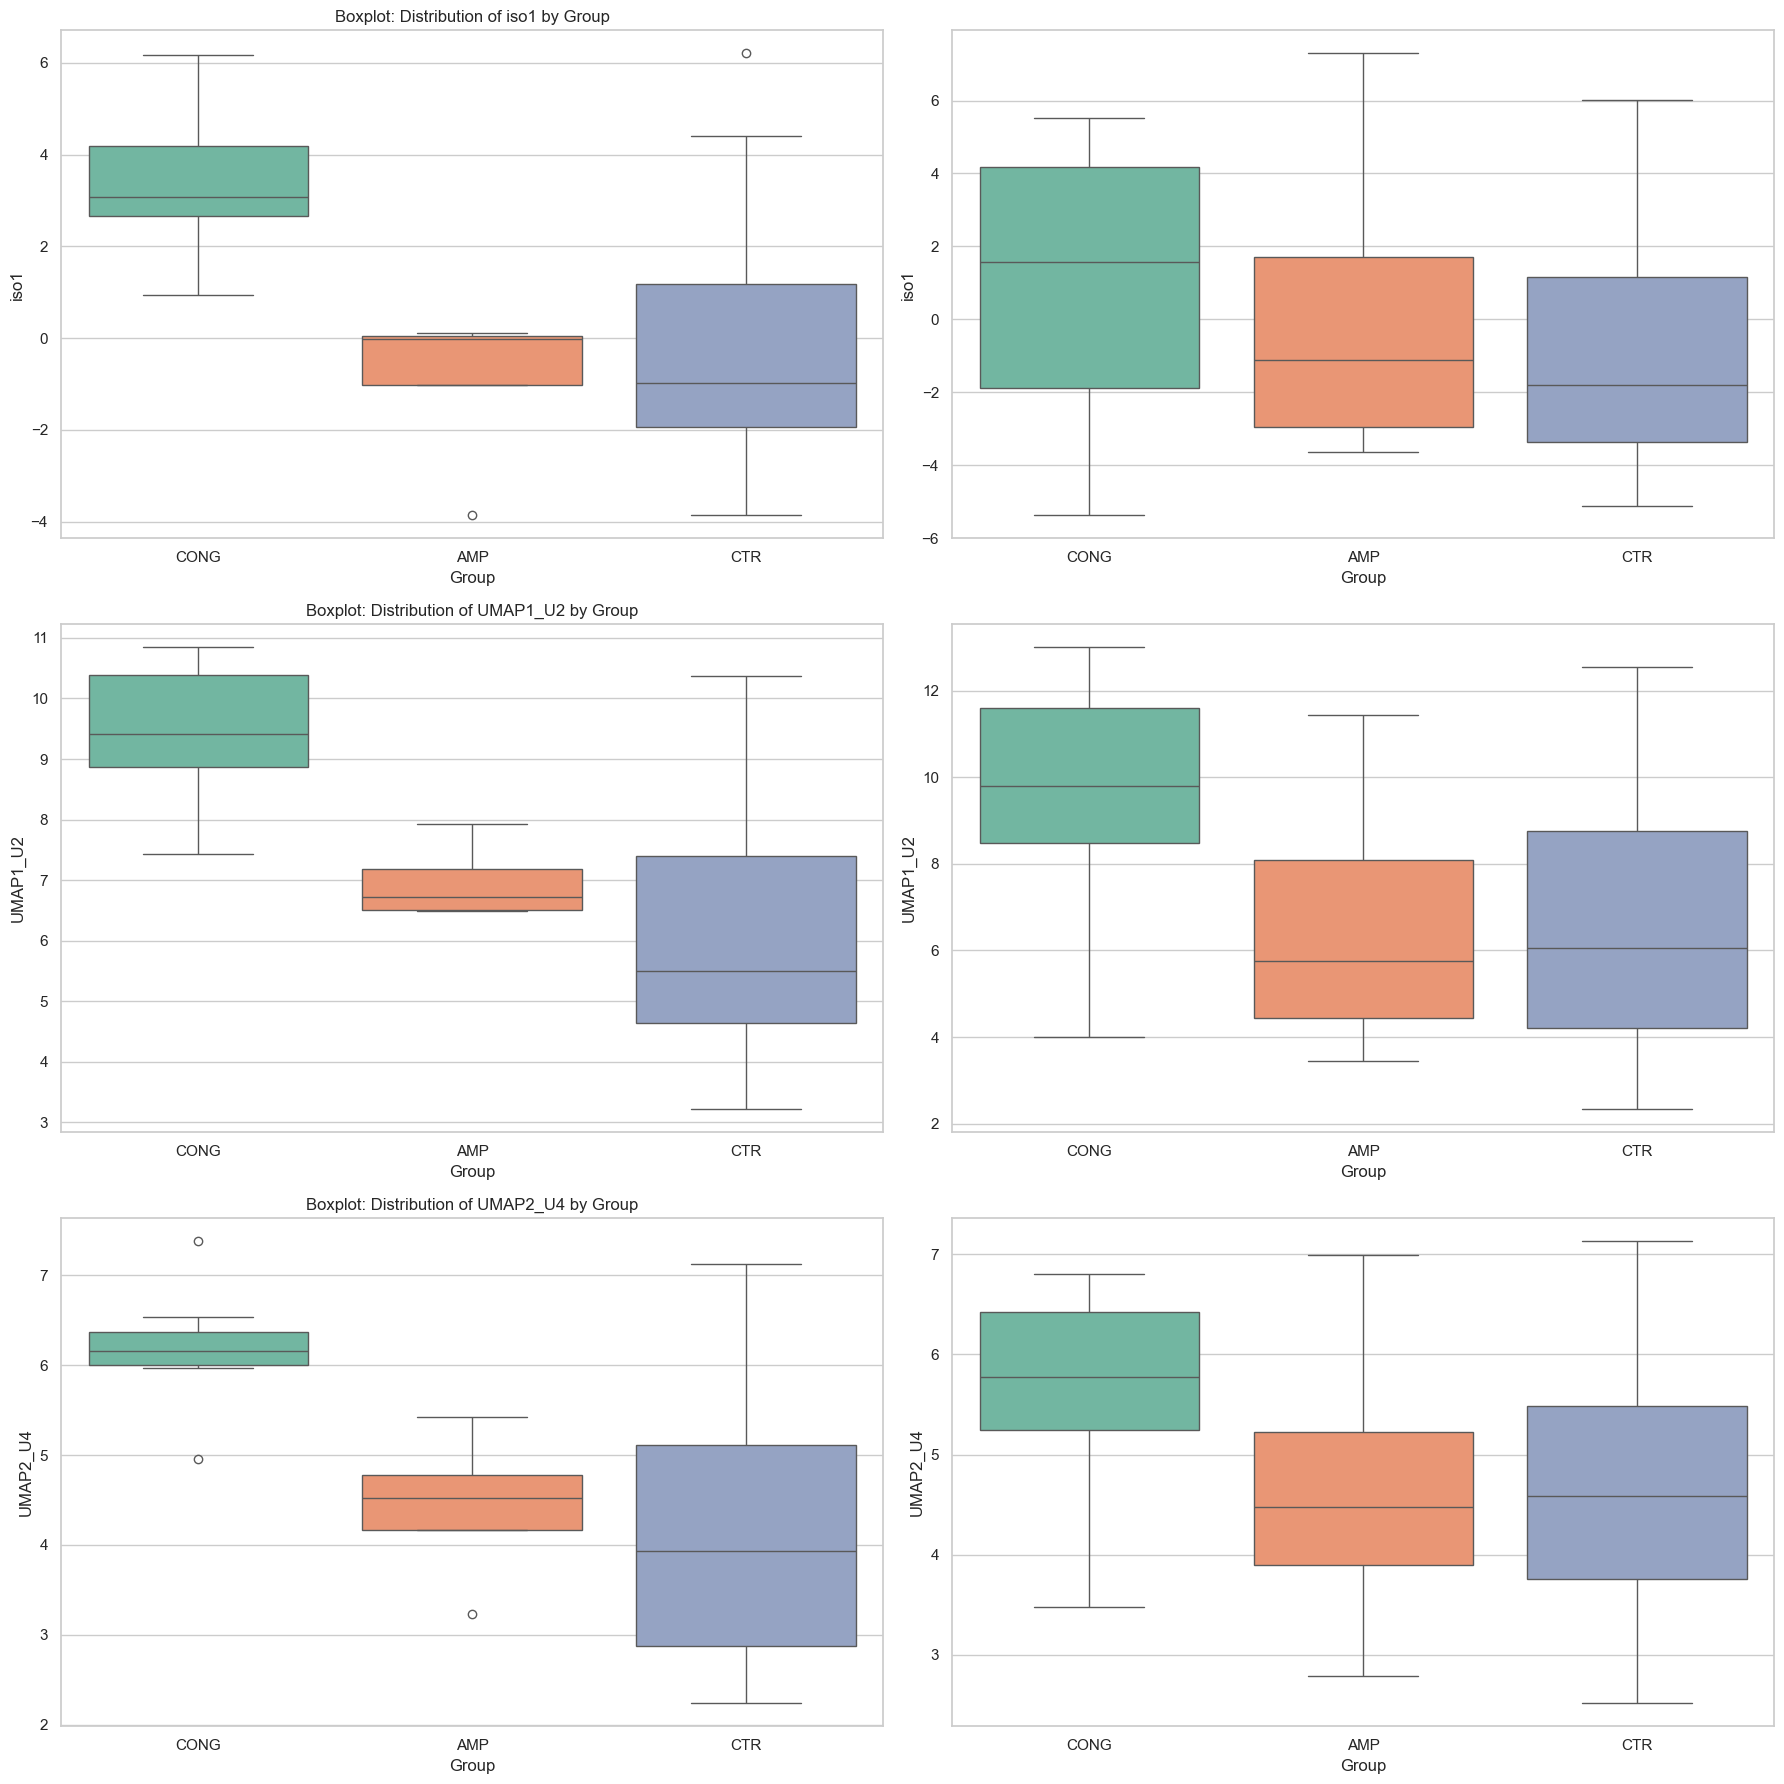

In [148]:
# Set the style of the visualization
sns.set(style="whitegrid")

# Create a figure with 3 rows and 2 columns
fig, axes = plt.subplots(3, 2, figsize=(18, 18))

# List of shape measures
shape_measures = ['iso1', 'UMAP1_U2', 'UMAP2_U4']

# Loop through the shape measures and create plots
for i, shape in enumerate(shape_measures):
    # Boxplot
    sns.boxplot(x='Group', y=shape, data=contraCtrL, palette='Set2', ax=axes[i, 0])
    axes[i, 0].set_title(f'Boxplot: Distribution of {shape} by Group')
    axes[i, 0].set_xlabel('Group')
    axes[i, 0].set_ylabel(shape)

    sns.boxplot(x='Group', y=shape, data=contraCtrR, palette='Set2', ax=axes[i, 1])
    axes[i, 0].set_title(f'Boxplot: Distribution of {shape} by Group')
    axes[i, 0].set_xlabel('Group')
    axes[i, 0].set_ylabel(shape)
    
"""
    # Violin Plot
    sns.violinplot(x='Group', y=shape, data=ipsiCtrR, palette='Set2', inner='quartile', ax=axes[i, 1])
    axes[i, 1].set_title(f'Violin Plot: Distribution of {shape} by Group')
    axes[i, 1].set_xlabel('Group')
    axes[i, 1].set_ylabel(shape)
"""
# save the plot
#plt.savefig(r'D:\B_projWIP\proj_amputee\plots\box_violin_iso1_U12_U24_ipsiR.png')
# Adjust layout
plt.tight_layout()
plt.show()

In [65]:
#########################  For functional activations  ##########################

# For activation analysis: select congenital data, contra
congContraL_function = joined_info_function[
    (joined_info_function['contraAmpSide'] == joined_info_function['side']) &
    (joined_info_function['side'] == 'L')
]
congContraR_function = joined_info_function[
    (joined_info_function['contraAmpSide'] == joined_info_function['side']) &
    (joined_info_function['side'] == 'R')
]
congContra_function = pd.concat([congContraL_function, congContraR_function], axis=0)
# select congenital data, ipsi
congIpsiL_function = joined_info_function[
    (joined_info_function['amp.side'] == 0) & (joined_info_function['side'] == 'L')
]
congIpsiR_function = joined_info_function[
(joined_info_function['amp.side'] == 1) & (joined_info_function['side'] == 'R')
]
congIpsi_function = pd.concat([congIpsiL_function, congIpsiR_function], axis=0)

print('congContra_function:')
print(len(congContra_function))
print(congContra_function.columns)
print('congIpsi_function:')
print(len(congIpsi_function))
print(congIpsi_function.columns)


congContra_function:
24
Index(['study', 'gender', 'amp.side', 'birthyear', 'Prosthesisusage',
       'Stumpusage', 'amputatio level', 'Cos', 'Fun', 'Myo', 'missinghand',
       'intacthand', 'residualarm', 'intactarm', 'lips', 'feet', 'side',
       'contraAmpSide', 'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2',
       'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4'],
      dtype='object')
congIpsi_function:
24
Index(['study', 'gender', 'amp.side', 'birthyear', 'Prosthesisusage',
       'Stumpusage', 'amputatio level', 'Cos', 'Fun', 'Myo', 'missinghand',
       'intacthand', 'residualarm', 'intactarm', 'lips', 'feet', 'side',
       'contraAmpSide', 'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2',
       'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4'],
      dtype='object')


In [66]:
###############################  Data Inspect  ##################################

In [140]:
curMeasure = 'UMAP1_U2'
grouped_data = contra.groupby('Group', observed=False)[curMeasure].describe()
print(grouped_data)
print()
grouped_data = ipsi.groupby('Group', observed=False)[curMeasure].describe()
print(grouped_data)

       count      mean       std       min       25%       50%        75%  \
Group                                                                       
AMP     16.0  6.548502  2.295542  3.457742  4.921346  6.505401   7.699556   
CONG    25.0  9.642470  2.009536  4.005999  8.525074  9.670146  10.841714   
CTR     48.0  6.529813  2.706461  2.336090  4.478419  6.017581   8.541769   

             max  
Group             
AMP    11.434205  
CONG   12.994308  
CTR    12.538661  

       count      mean       std       min       25%       50%       75%  \
Group                                                                      
AMP     16.0  7.122498  2.543470  2.712205  5.455531  6.991426  9.113992   
CONG    25.0  6.872853  2.949730  2.309569  4.255821  6.775525  9.342570   
CTR     48.0  6.529813  2.706461  2.336090  4.478419  6.017581  8.541769   

             max  
Group             
AMP    11.058319  
CONG   12.772156  
CTR    12.538661  


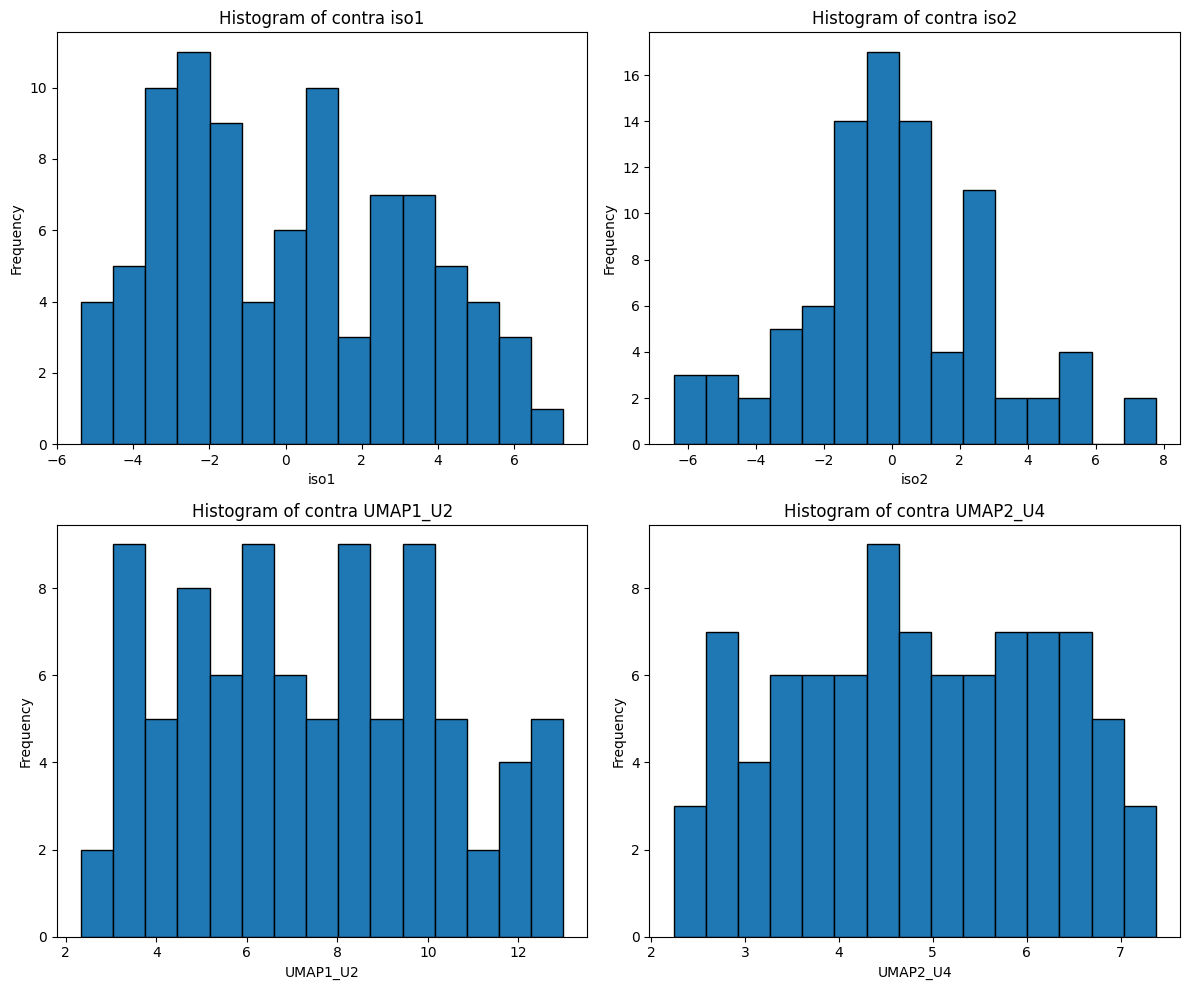

In [68]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Plot the histogram for 'iso1'
axs[0, 0].hist(contra['iso1'], bins=15, edgecolor='black')
axs[0, 0].set_title('Histogram of contra iso1')
axs[0, 0].set_xlabel('iso1')
axs[0, 0].set_ylabel('Frequency')

# Plot the histogram for 'iso2'
axs[0, 1].hist(contra['iso2'], bins=15, edgecolor='black')
axs[0, 1].set_title('Histogram of contra iso2')
axs[0, 1].set_xlabel('iso2')
axs[0, 1].set_ylabel('Frequency')

# Plot the histogram for 'iso3'
axs[1, 0].hist(contra['UMAP1_U2'], bins=15, edgecolor='black')
axs[1, 0].set_title('Histogram of contra UMAP1_U2')
axs[1, 0].set_xlabel('UMAP1_U2')
axs[1, 0].set_ylabel('Frequency')

# Plot the histogram for 'Umap'
axs[1, 1].hist(contra['UMAP2_U4'], bins=15, edgecolor='black')
axs[1, 1].set_title('Histogram of contra UMAP2_U4')
axs[1, 1].set_xlabel('UMAP2_U4')
axs[1, 1].set_ylabel('Frequency')

# Adjust layout
plt.tight_layout()
# save the plot
#plt.savefig(r'D:\B_projWIP\proj_amputee\plots\hist_iso1_iso2_U12_U24_contra.png')
# Show the plot
plt.show()

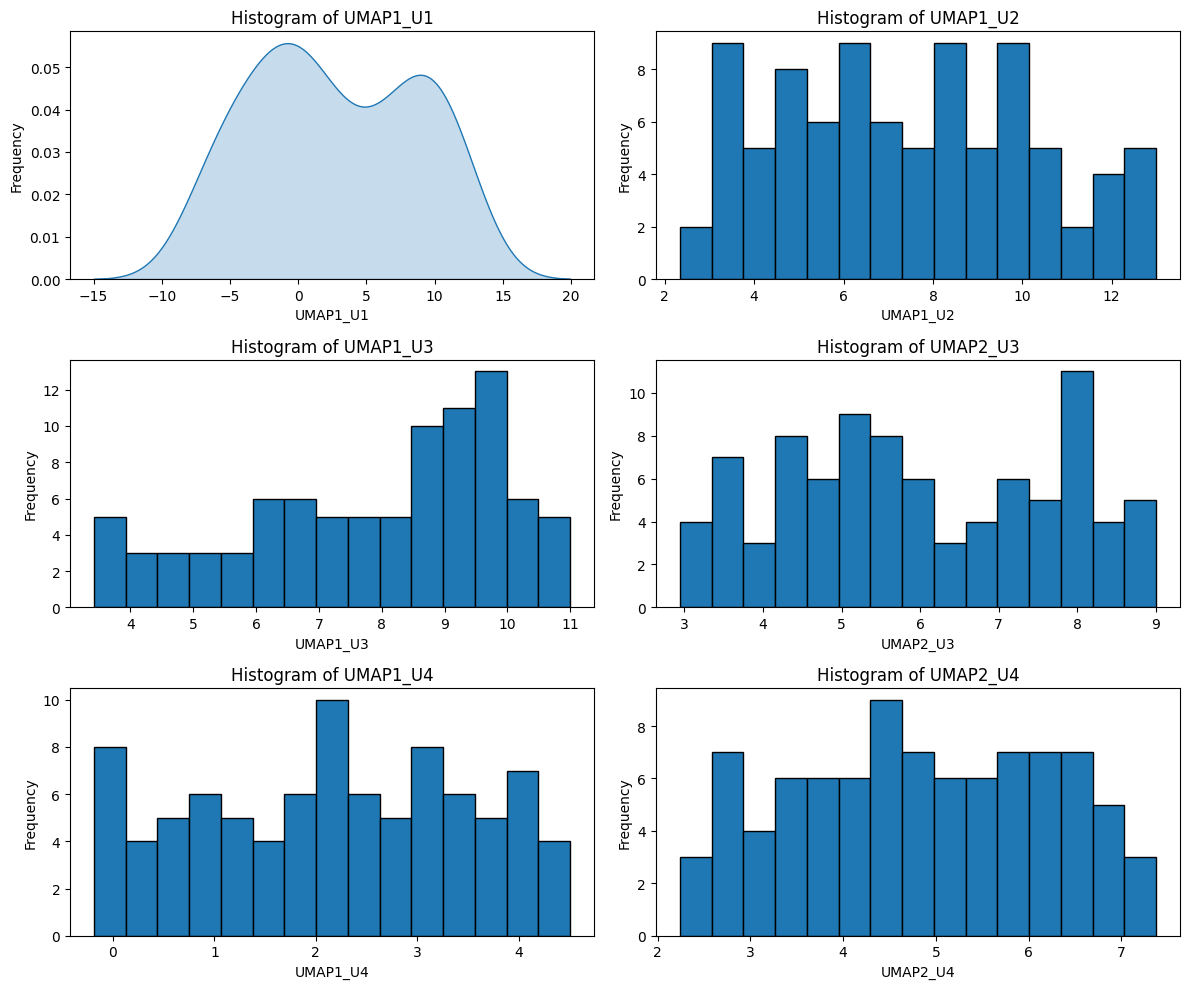

In [69]:
fig, axs = plt.subplots(3, 2, figsize=(12, 10))

# Plot the histogram for 'UMAP1_U1'
#axs[0, 0].hist(contra['UMAP1_U1'], bins=15, edgecolor='black')
sns.kdeplot(data=contra['UMAP1_U1'], fill=True, ax=axs[0, 0])
axs[0, 0].set_title('Histogram of UMAP1_U1')
axs[0, 0].set_xlabel('UMAP1_U1')
axs[0, 0].set_ylabel('Frequency')
# Plot the histogram for 'UMAP1_U2'
axs[0, 1].hist(contra['UMAP1_U2'], bins=15, edgecolor='black')
axs[0, 1].set_title('Histogram of UMAP1_U2')
axs[0, 1].set_xlabel('UMAP1_U2')
axs[0, 1].set_ylabel('Frequency')

# Plot the histogram for 'UMAP1_U3'
axs[1, 0].hist(contra['UMAP1_U3'], bins=15, edgecolor='black')
axs[1, 0].set_title('Histogram of UMAP1_U3')
axs[1, 0].set_xlabel('UMAP1_U3')
axs[1, 0].set_ylabel('Frequency')
# Plot the histogram for 'UMAP2_U3'
axs[1, 1].hist(contra['UMAP2_U3'], bins=15, edgecolor='black')
axs[1, 1].set_title('Histogram of UMAP2_U3')
axs[1, 1].set_xlabel('UMAP2_U3')
axs[1, 1].set_ylabel('Frequency')

# Plot the histogram for 'UMAP1_U4'
axs[2, 0].hist(contra['UMAP1_U4'], bins=15, edgecolor='black')
axs[2, 0].set_title('Histogram of UMAP1_U4')
axs[2, 0].set_xlabel('UMAP1_U4')
axs[2, 0].set_ylabel('Frequency')
# Plot the histogram for 'UMAP2_U4'
axs[2, 1].hist(contra['UMAP2_U4'], bins=15, edgecolor='black')
axs[2, 1].set_title('Histogram of UMAP2_U4')
axs[2, 1].set_xlabel('UMAP2_U4')
axs[2, 1].set_ylabel('Frequency')
# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

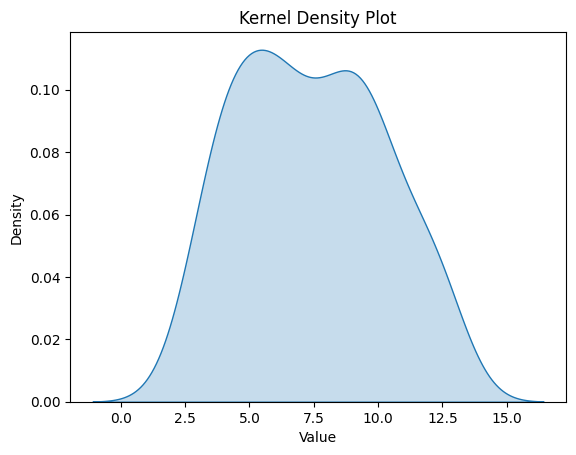

In [70]:
data = contra['UMAP1_U2']

# Create a kernel density plot
sns.kdeplot(data, fill=True)
plt.title('Kernel Density Plot')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

In [71]:
print(contra)

           Gender  AgeScan  AgeLimbLoss Group AmpSide DominantHand      iso1  \
LPA04           F       52          0.0  CONG       R          NaN  2.580672   
LPA10           F       25          0.0  CONG       R          NaN  3.319457   
LPA21           F       34          0.0  CONG       R          NaN  3.084241   
LPA22           F       36          0.0  CONG       R          NaN  6.178370   
LMA03           M       35          0.0  CONG       R          NaN  2.758103   
...           ...      ...          ...   ...     ...          ...       ...   
flip-RPC20      F       40          NaN   CTR     NaN            R -2.903036   
flip-RPC21      M       52          NaN   CTR     NaN            L -5.109851   
flip-RPC22      F       62          NaN   CTR     NaN            R -1.124470   
flip-RPC23      F       25          NaN   CTR     NaN            R -4.130698   
flip-RPC24      M       64          NaN   CTR     NaN            L  0.558929   

                iso2      iso3   UMAP1_

Text(0, 0.5, 'Density')

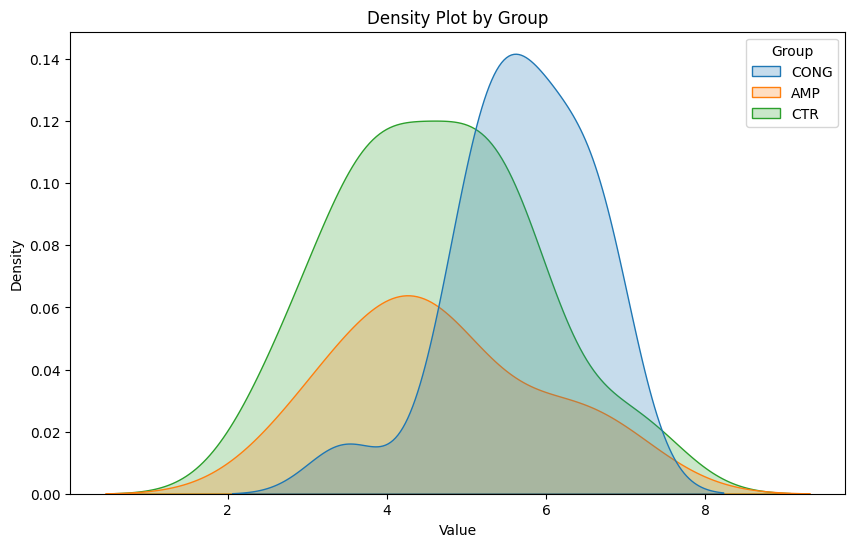

In [72]:
# Create the density plot
plt.figure(figsize=(10, 6))
sns.kdeplot(data=contraCtrR, x='UMAP2_U4', hue='Group', fill=True)

# Customize the plot
plt.title('Density Plot by Group')
plt.xlabel('Value')
plt.ylabel('Density')


C:\Users\joyca\AppData\Local\Temp\ipykernel_38748\1491474966.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=contra, x='Group', y='UMAP1_U2', jitter=True, palette=custom_palette)


Text(0, 0.5, 'Value')

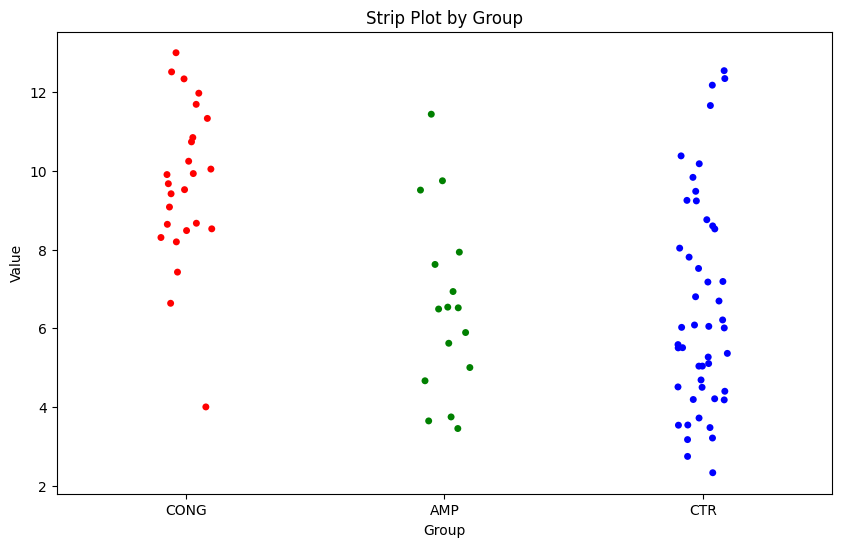

In [73]:
custom_palette = {'CONG': 'red', 'AMP': 'green', 'CTR': 'blue'}

# Create the strip plot
plt.figure(figsize=(10, 6))
sns.stripplot(data=contra, x='Group', y='UMAP1_U2', jitter=True, palette=custom_palette)

# Customize the plot
plt.title('Strip Plot by Group')
plt.xlabel('Group')
plt.ylabel('Value')


C:\Users\joyca\AppData\Local\Temp\ipykernel_38748\2789345392.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=contra, x='Group', y='UMAP1_U2', palette=custom_palette)


Text(92.09722222222221, 0.5, 'Value')

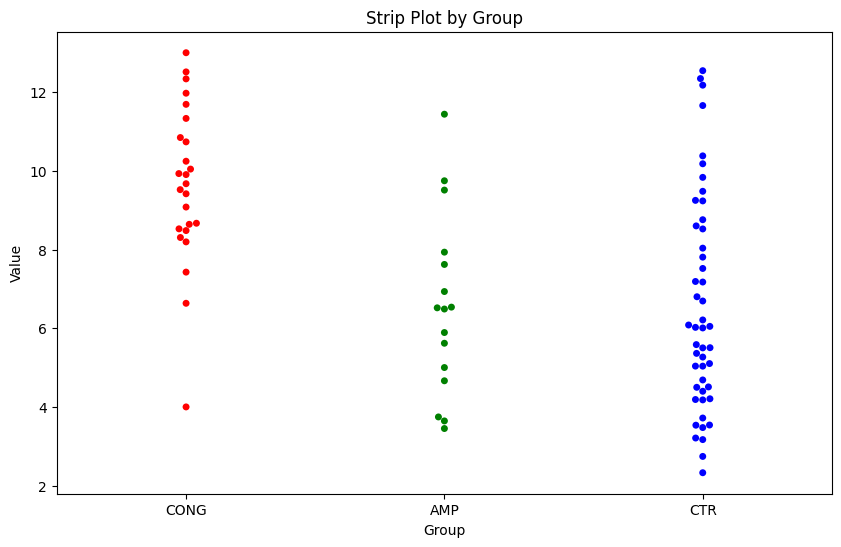

In [74]:
custom_palette = {'CONG': 'red', 'AMP': 'green', 'CTR': 'blue'}
# Create the strip plot
plt.figure(figsize=(10, 6))
sns.swarmplot(data=contra, x='Group', y='UMAP1_U2', palette=custom_palette)
# Customize the plot
plt.title('Strip Plot by Group')
plt.xlabel('Group')
plt.ylabel('Value')

C:\Users\joyca\AppData\Local\Temp\ipykernel_38748\513083306.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='UMAP1_U2', data=contra, palette='Set2', ax=axes[0])
C:\Users\joyca\AppData\Local\Temp\ipykernel_38748\513083306.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Group', y='iso1', data=contra, palette='Set2', inner='quartile', ax=axes[1])


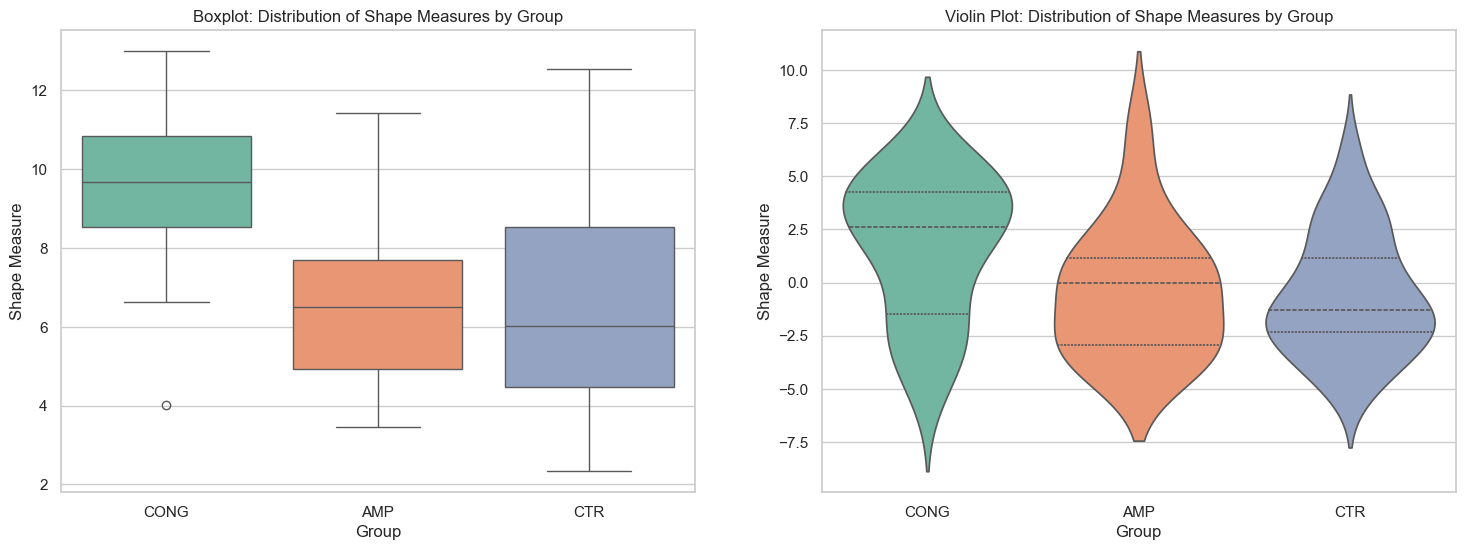

In [132]:
# Set the style of the visualization
sns.set(style="whitegrid")
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Boxplot
sns.boxplot(x='Group', y='UMAP1_U2', data=contra, palette='Set2', ax=axes[0])
axes[0].set_title('Boxplot: Distribution of Shape Measures by Group')
axes[0].set_xlabel('Group')
axes[0].set_ylabel('Shape Measure')
# Violin Plot
sns.violinplot(x='Group', y='iso1', data=contra, palette='Set2', inner='quartile', ax=axes[1])
axes[1].set_title('Violin Plot: Distribution of Shape Measures by Group')
axes[1].set_xlabel('Group')
axes[1].set_ylabel('Shape Measure')
# save the plot
#plt.savefig(r'D:\B_projWIP\proj_amputee\plots\box_violin_iso1_contra.png')
# Show the plot
plt.show()

C:\Users\joyca\AppData\Local\Temp\ipykernel_38748\1108586590.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='iso1', data=contra, palette='Set2', ax=axes[0])
C:\Users\joyca\AppData\Local\Temp\ipykernel_38748\1108586590.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Group', y='iso1', data=contra, palette='Set2', inner='quartile', ax=axes[1])


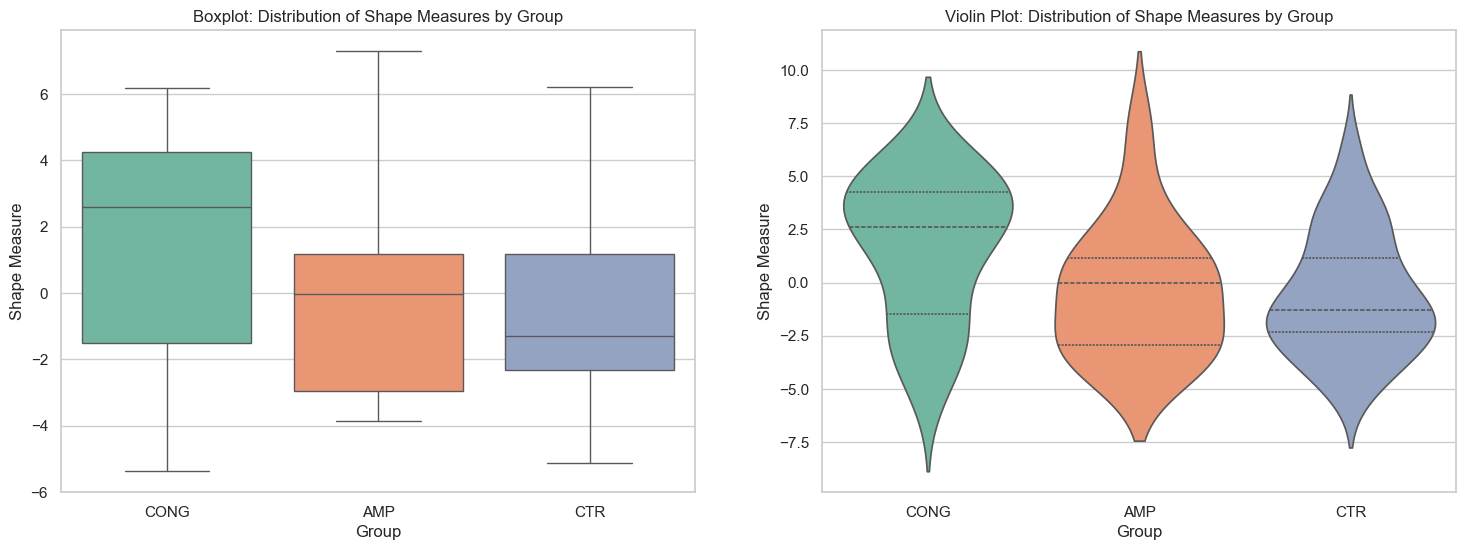

In [76]:
# Set the style of the visualization
sns.set(style="whitegrid")
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Boxplot
sns.boxplot(x='Group', y='iso1', data=contra, palette='Set2', ax=axes[0])
axes[0].set_title('Boxplot: Distribution of Shape Measures by Group')
axes[0].set_xlabel('Group')
axes[0].set_ylabel('Shape Measure')
# Violin Plot
sns.violinplot(x='Group', y='iso1', data=contra, palette='Set2', inner='quartile', ax=axes[1])
axes[1].set_title('Violin Plot: Distribution of Shape Measures by Group')
axes[1].set_xlabel('Group')
axes[1].set_ylabel('Shape Measure')

# Show the plot
plt.show()

C:\Users\joyca\AppData\Local\Temp\ipykernel_38748\382539001.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=shape, data=ipsiCtrR, palette='Set2', ax=axes[i, 0])
C:\Users\joyca\AppData\Local\Temp\ipykernel_38748\382539001.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Group', y=shape, data=ipsiCtrR, palette='Set2', inner='quartile', ax=axes[i, 1])
C:\Users\joyca\AppData\Local\Temp\ipykernel_38748\382539001.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=shape, data=ipsiCtrR, palette='Set2', ax=a

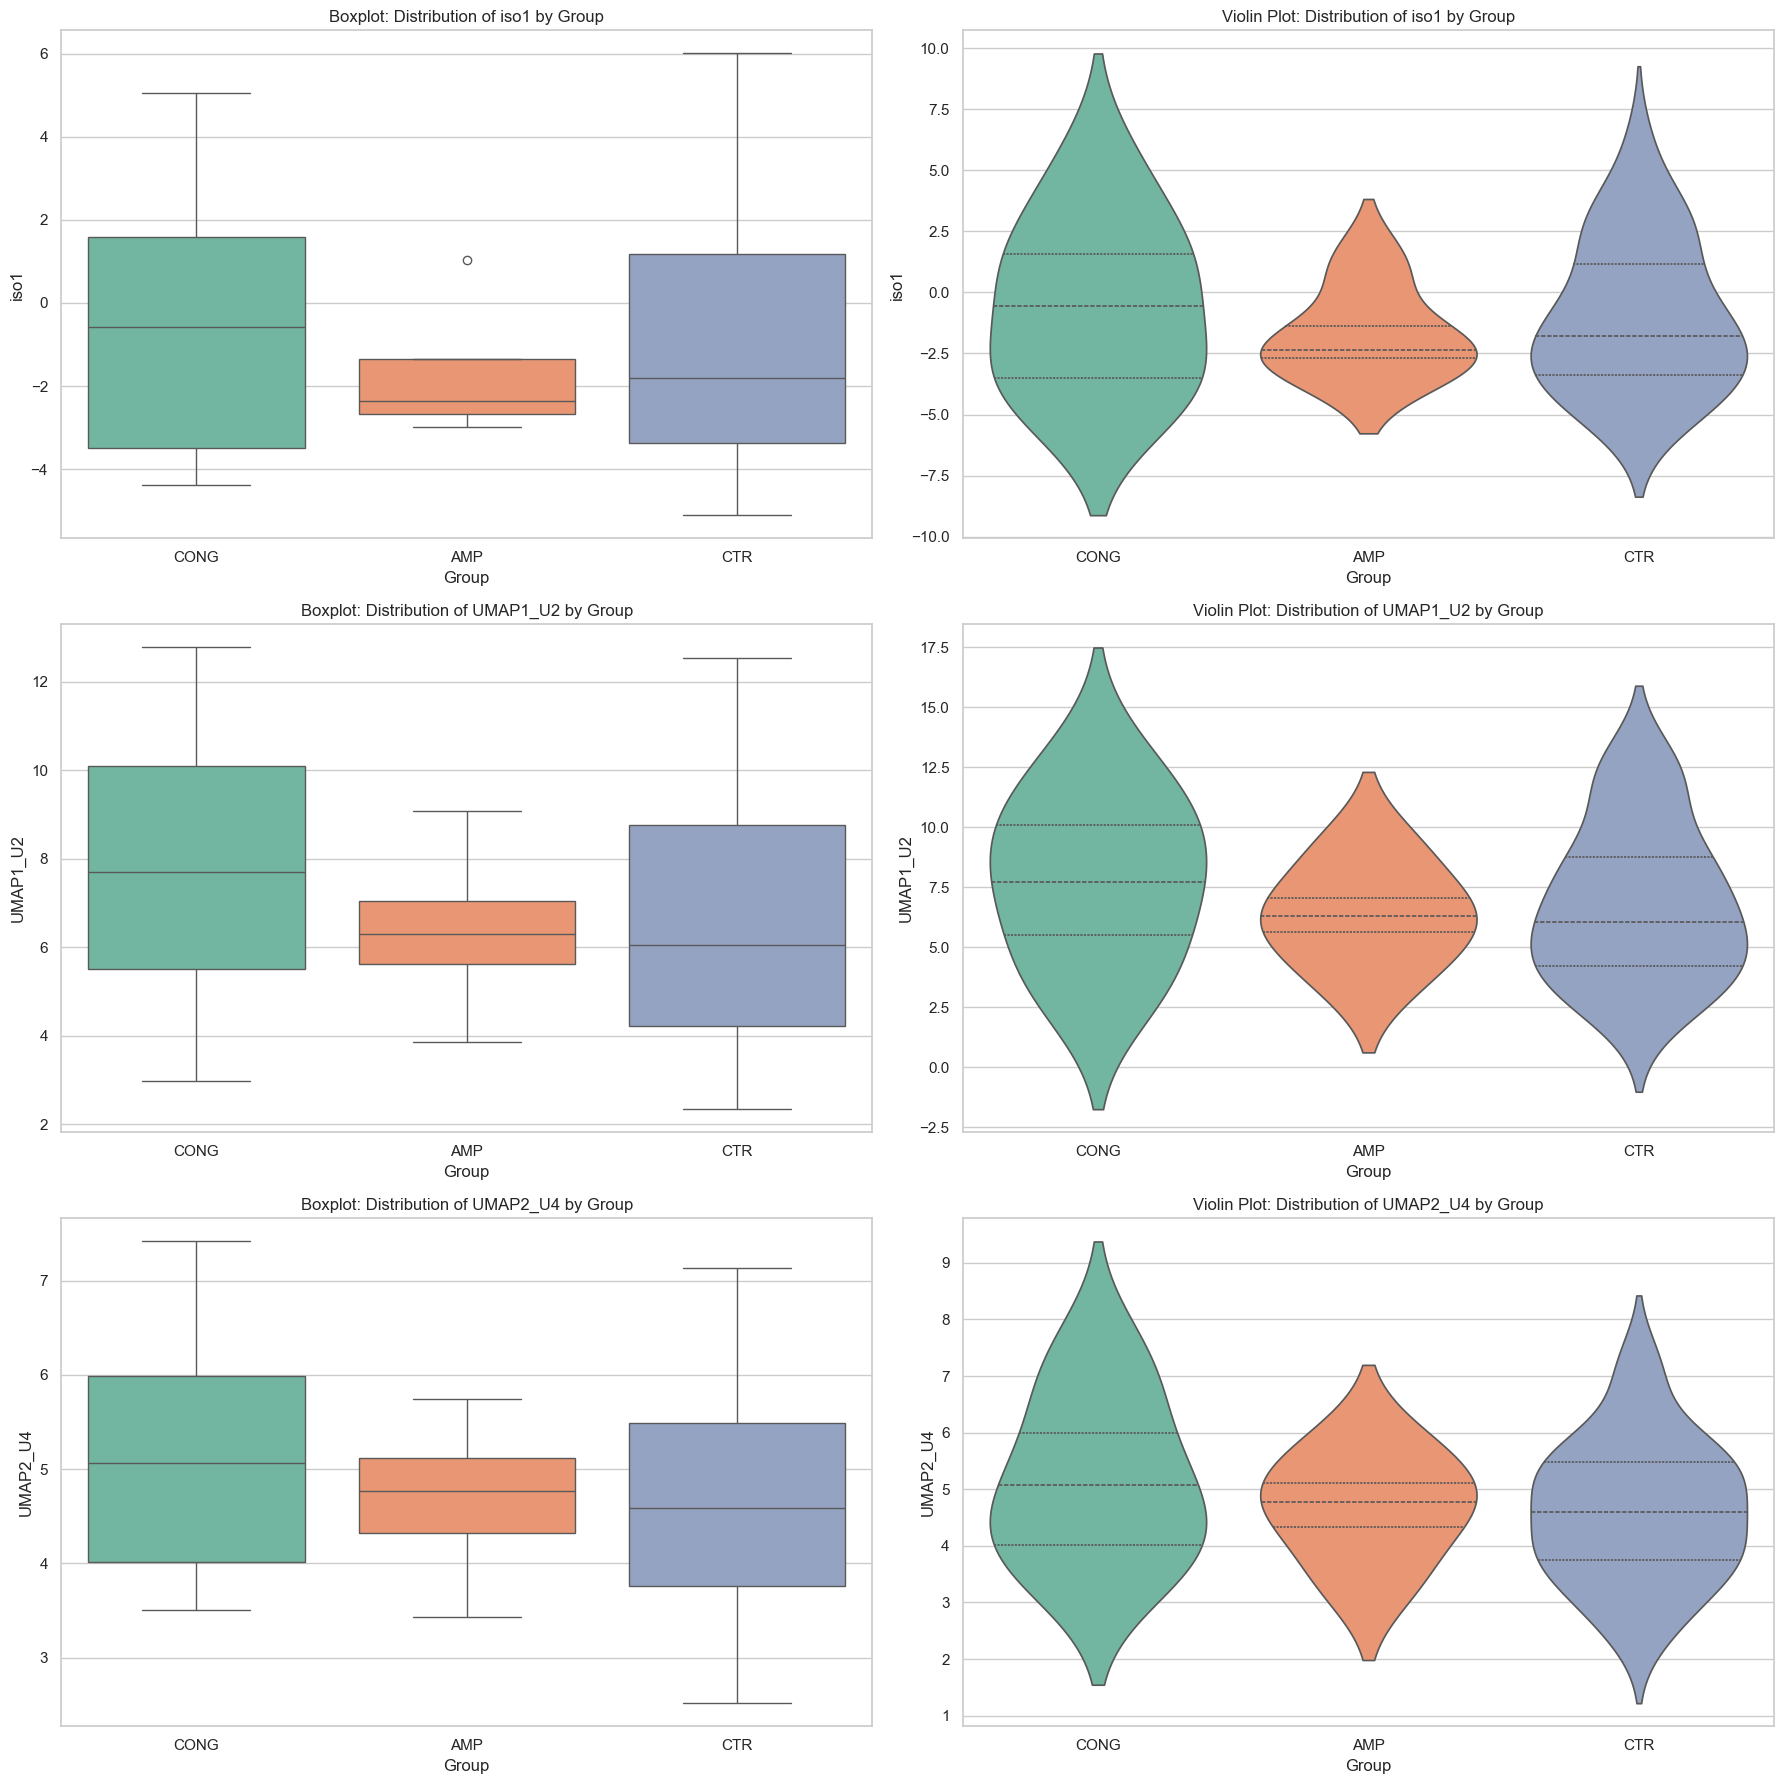

In [77]:
# Set the style of the visualization
sns.set(style="whitegrid")

# Create a figure with 3 rows and 2 columns
fig, axes = plt.subplots(3, 2, figsize=(18, 18))

# List of shape measures
shape_measures = ['iso1', 'UMAP1_U2', 'UMAP2_U4']

# Loop through the shape measures and create plots
for i, shape in enumerate(shape_measures):
    # Boxplot
    sns.boxplot(x='Group', y=shape, data=ipsiCtrR, palette='Set2', ax=axes[i, 0])
    axes[i, 0].set_title(f'Boxplot: Distribution of {shape} by Group')
    axes[i, 0].set_xlabel('Group')
    axes[i, 0].set_ylabel(shape)

    # Violin Plot
    sns.violinplot(x='Group', y=shape, data=ipsiCtrR, palette='Set2', inner='quartile', ax=axes[i, 1])
    axes[i, 1].set_title(f'Violin Plot: Distribution of {shape} by Group')
    axes[i, 1].set_xlabel('Group')
    axes[i, 1].set_ylabel(shape)
# save the plot
#plt.savefig(r'D:\B_projWIP\proj_amputee\plots\box_violin_iso1_U12_U24_ipsiR.png')
# Adjust layout
plt.tight_layout()
plt.show()

C:\Users\joyca\AppData\Local\Temp\ipykernel_38748\164874173.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=shape, data=contraCtrL, palette='Set2', ax=axes[i, 0])
C:\Users\joyca\AppData\Local\Temp\ipykernel_38748\164874173.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=shape, data=contraCtrR, palette='Set2', ax=axes[i, 1])
C:\Users\joyca\AppData\Local\Temp\ipykernel_38748\164874173.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=shape, data=contraCtrL, palette='Set2', ax=axes[i, 0])
C:\U

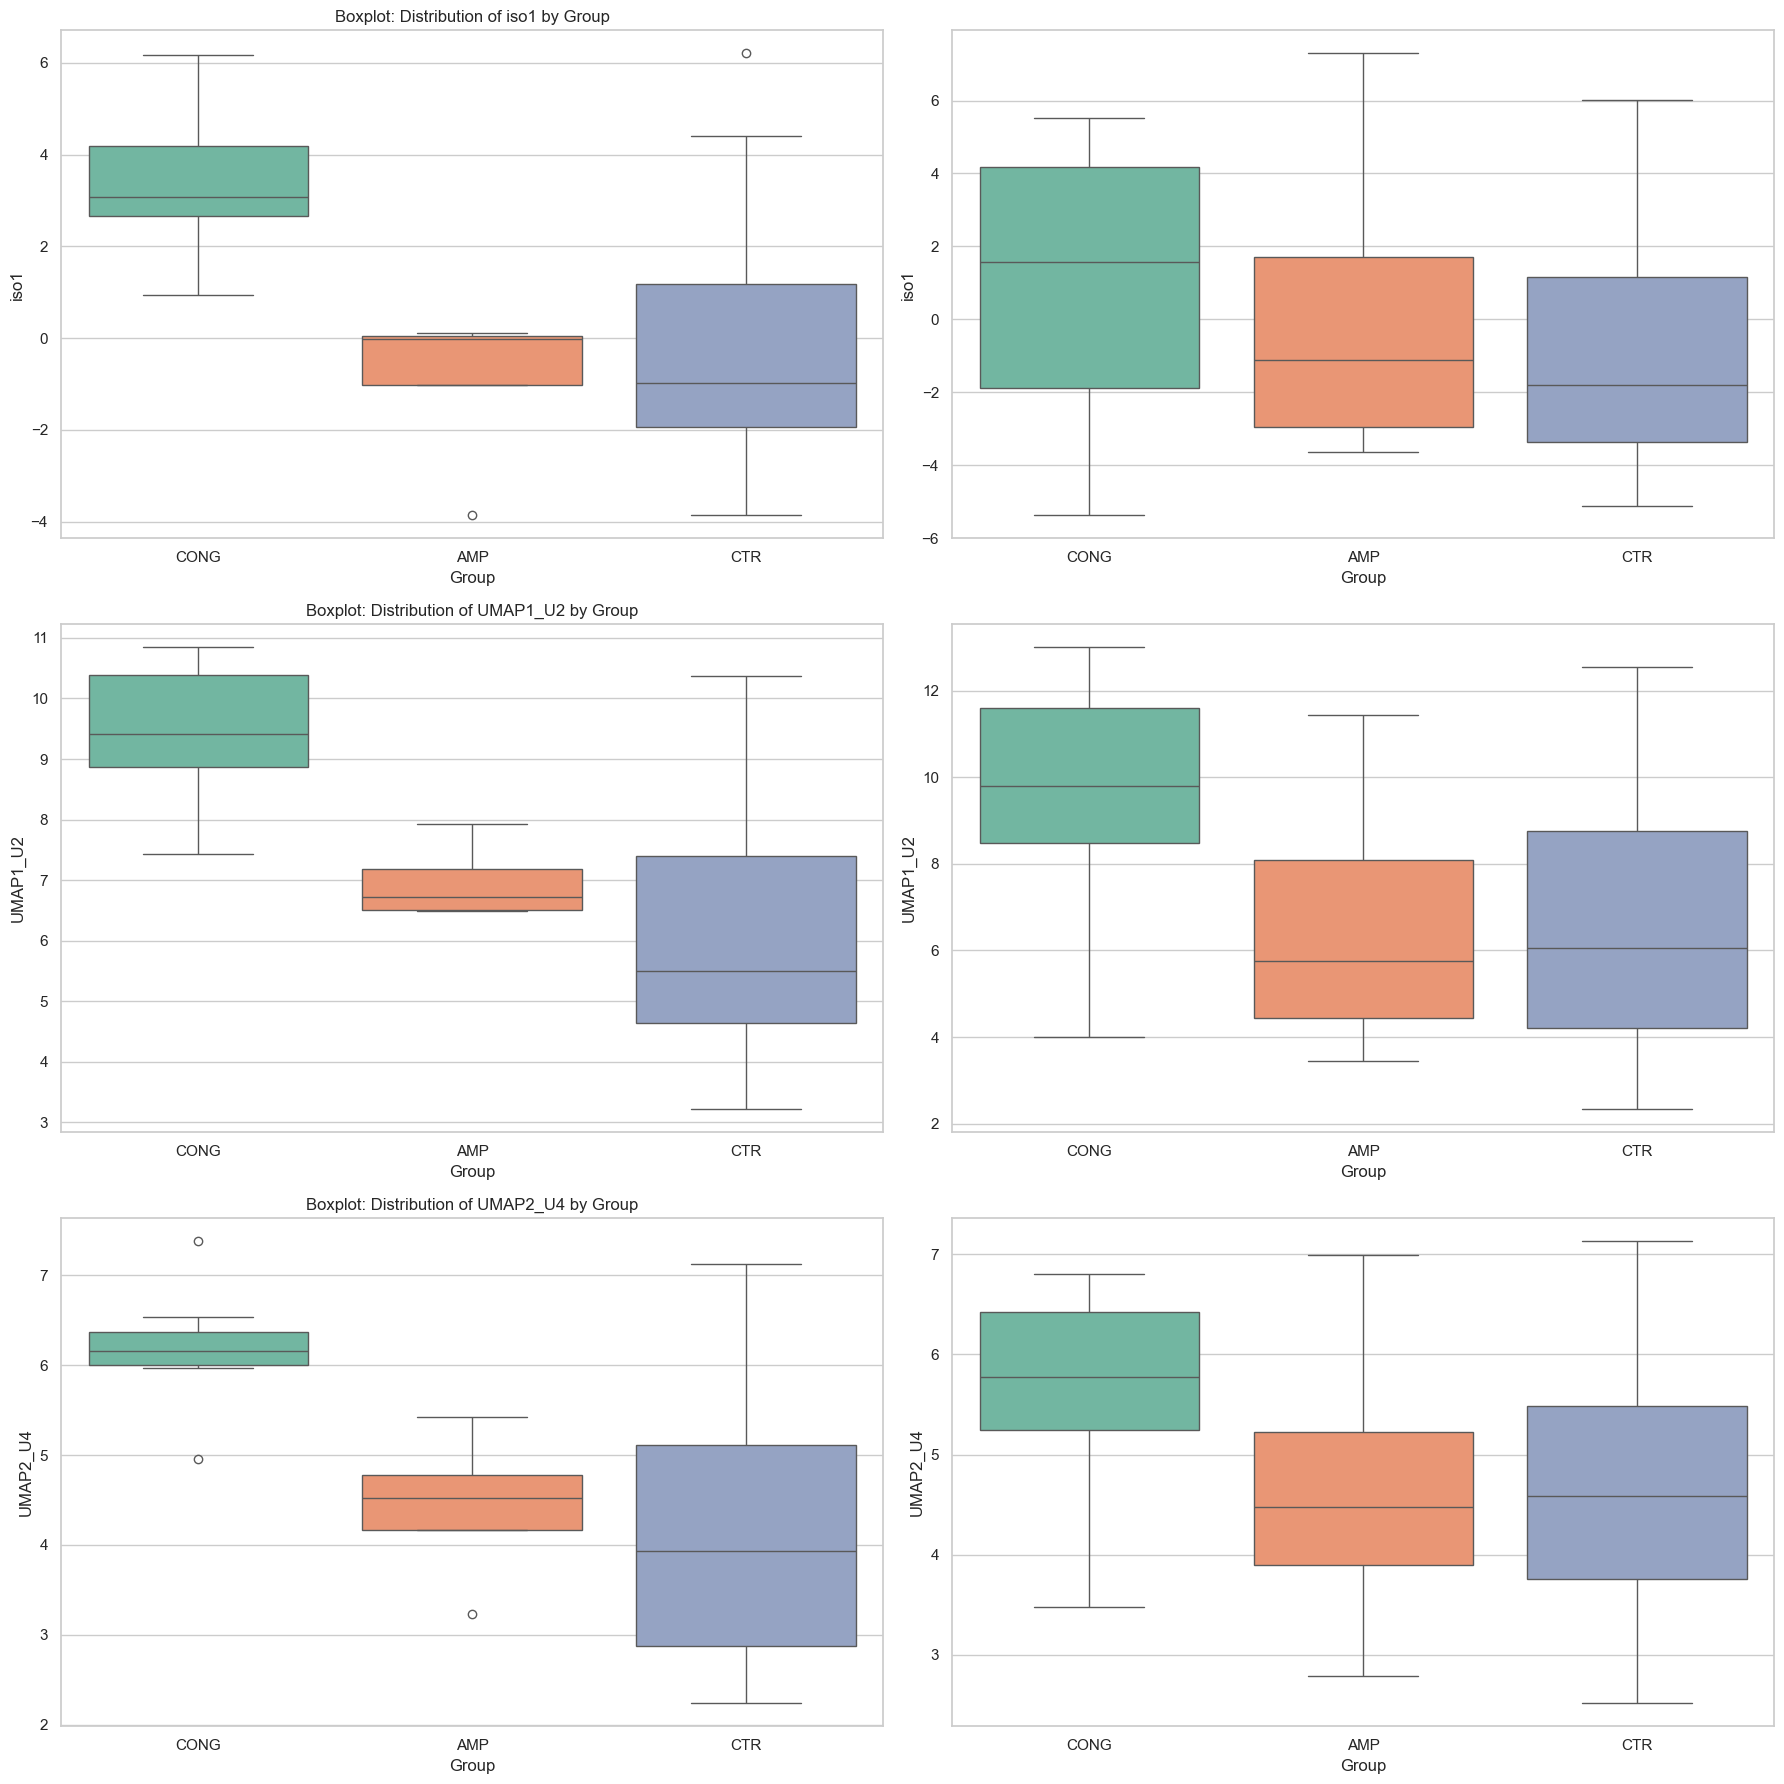

In [136]:
# Set the style of the visualization
sns.set(style="whitegrid")

# Create a figure with 3 rows and 2 columns
fig, axes = plt.subplots(3, 2, figsize=(18, 18))

# List of shape measures
shape_measures = ['iso1', 'UMAP1_U2', 'UMAP2_U4']

# Loop through the shape measures and create plots
for i, shape in enumerate(shape_measures):
    # Boxplot
    sns.boxplot(x='Group', y=shape, data=contraCtrL, palette='Set2', ax=axes[i, 0])
    axes[i, 0].set_title(f'Boxplot: Distribution of {shape} by Group')
    axes[i, 0].set_xlabel('Group')
    axes[i, 0].set_ylabel(shape)

    sns.boxplot(x='Group', y=shape, data=contraCtrR, palette='Set2', ax=axes[i, 1])
    axes[i, 0].set_title(f'Boxplot: Distribution of {shape} by Group')
    axes[i, 0].set_xlabel('Group')
    axes[i, 0].set_ylabel(shape)
    
"""
    # Violin Plot
    sns.violinplot(x='Group', y=shape, data=ipsiCtrR, palette='Set2', inner='quartile', ax=axes[i, 1])
    axes[i, 1].set_title(f'Violin Plot: Distribution of {shape} by Group')
    axes[i, 1].set_xlabel('Group')
    axes[i, 1].set_ylabel(shape)
"""
# save the plot
#plt.savefig(r'D:\B_projWIP\proj_amputee\plots\box_violin_iso1_U12_U24_ipsiR.png')
# Adjust layout
plt.tight_layout()
plt.show()

Pearson Correlation: -0.578828388057134, p-value: 0.0030422286165351833


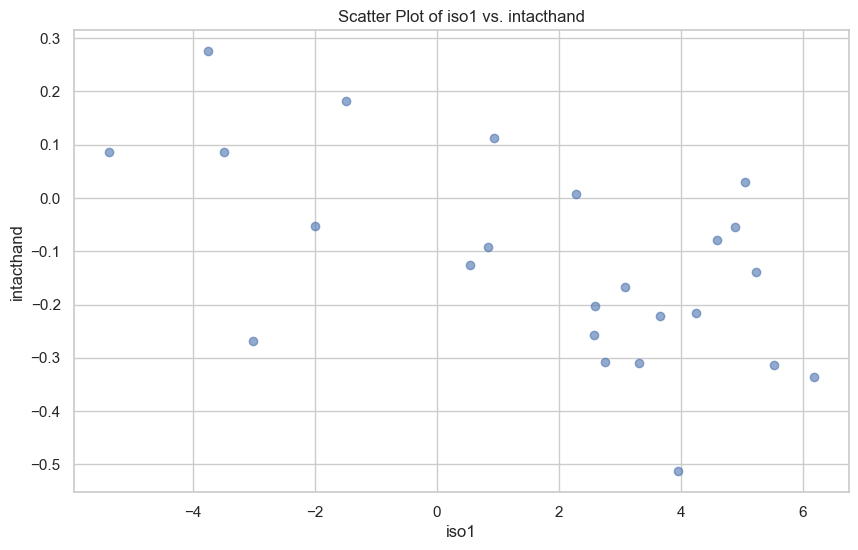

In [78]:
from scipy.stats import pearsonr

curMeasure = 'iso1' 
corMeasure = 'intacthand'
# Calculate Pearson correlation
pearson_corr, pearson_p_value = pearsonr(congContra_function[curMeasure], congContra_function['intacthand'])
print(f'Pearson Correlation: {pearson_corr}, p-value: {pearson_p_value}')

# Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(congContra_function[curMeasure], congContra_function[corMeasure], alpha=0.6)
plt.title(f'Scatter Plot of {curMeasure} vs. {corMeasure}')
plt.xlabel(curMeasure)
plt.ylabel(corMeasure)
plt.grid(True)
plt.show()

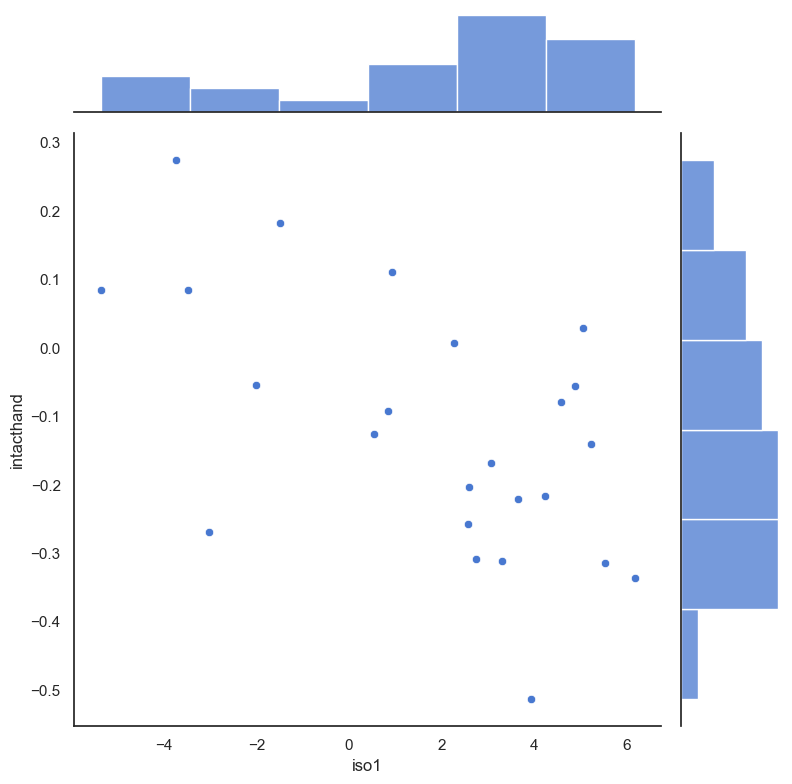

In [79]:
import numpy as np
# Joint Plot
curMeasure = 'iso1' 
corMeasure = 'intacthand'

congContra_function_no_inf = congContra_function.replace([np.inf, -np.inf], np.nan)  # Replace inf with NaN
sns.set(style="white", palette="muted")
sns.jointplot(x=curMeasure, y=corMeasure, data=congContra_function_no_inf, kind='scatter', height=8, ratio=5)
plt.show()

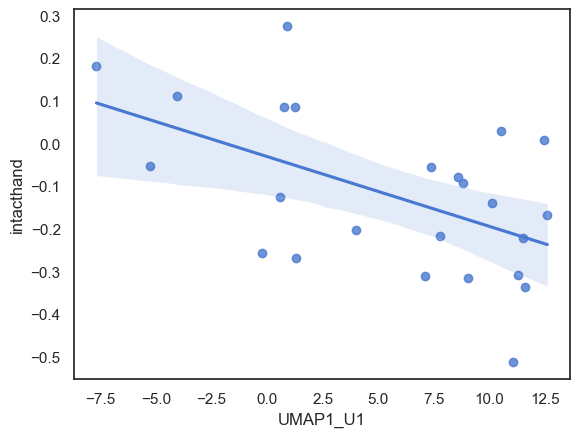

In [80]:
congContra_function_no_inf = congContra_function.replace([np.inf, -np.inf], np.nan)
curMeasure = 'UMAP1_U1' 
corMeasure = 'intacthand'
congContra_function_no_inf = congContra_function.replace([np.inf, -np.inf], np.nan)
sns.set(style="white", palette="muted")
sns.regplot(x=curMeasure, y=corMeasure, data=congContra_function_no_inf)  # Removed height and ratio arguments
plt.show()


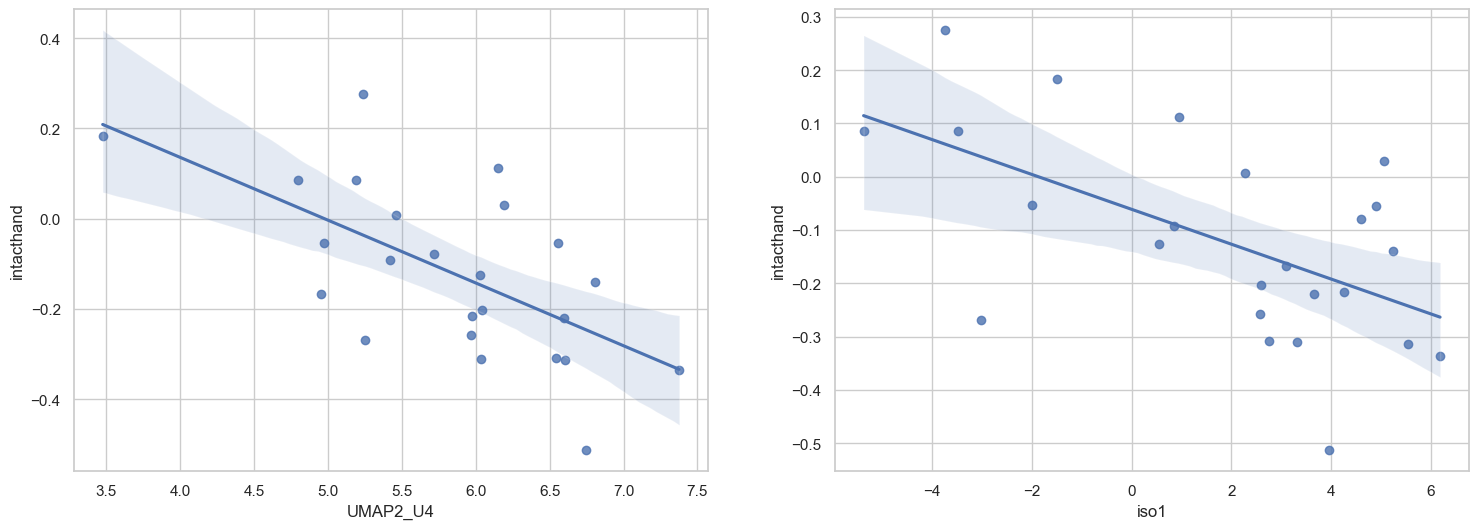

In [81]:
sns.set(style="whitegrid")
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

#congContra_function_no_inf = congContra_function.replace([np.inf, -np.inf], np.nan)
curMeasure = 'UMAP2_U4' 
corMeasure = 'intacthand'
congContra_function_no_inf = congContra_function.replace([np.inf, -np.inf], np.nan)
sns.set(style="white", palette="muted")
sns.regplot(x=curMeasure, y=corMeasure, data=congContra_function_no_inf,ax=axes[0])  # Removed height and ratio arguments

#congContra_function_no_inf = congContra_function.replace([np.inf, -np.inf], np.nan)
curMeasure = 'iso1' 
corMeasure = 'intacthand'
congContra_function_no_inf = congContra_function.replace([np.inf, -np.inf], np.nan)
sns.set(style="white", palette="muted")
sns.regplot(x=curMeasure, y=corMeasure, data=congContra_function_no_inf,ax=axes[1])  # Removed height and ratio arguments

plt.show()

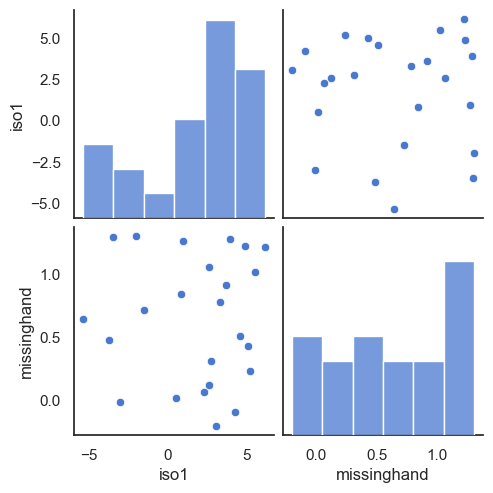

In [82]:
# Pair Plot
sns.pairplot(congContra_function[[curMeasure, 'missinghand']])
plt.show()

Text(0.5, 1.0, 'Correlation Matrix Heatmap')

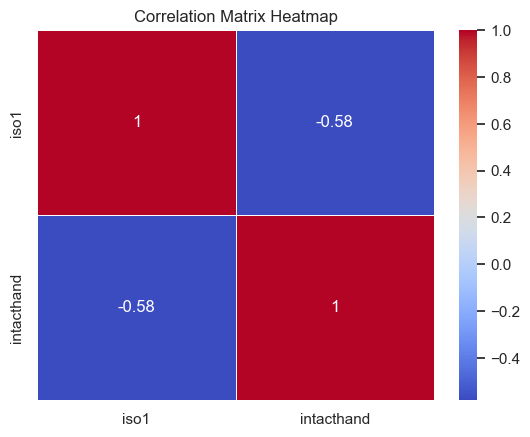

In [83]:
# Heatmap of Correlation Matrix
curMeasure = 'iso1' 
corMeasure = 'intacthand'
corr_matrix = congContra_function[[curMeasure, corMeasure]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')